# TensorFlow介绍
## 1）Tensorflow简介

发展历程  
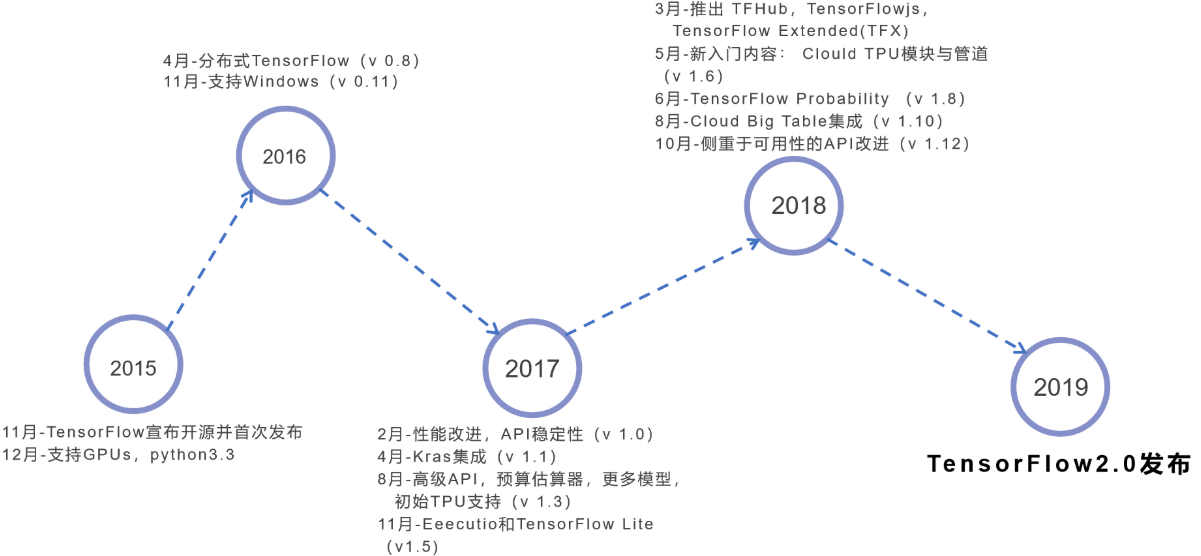

tensorflow生态：
- 开源生态成熟
- 完整的部署流程
- 产品化方案  
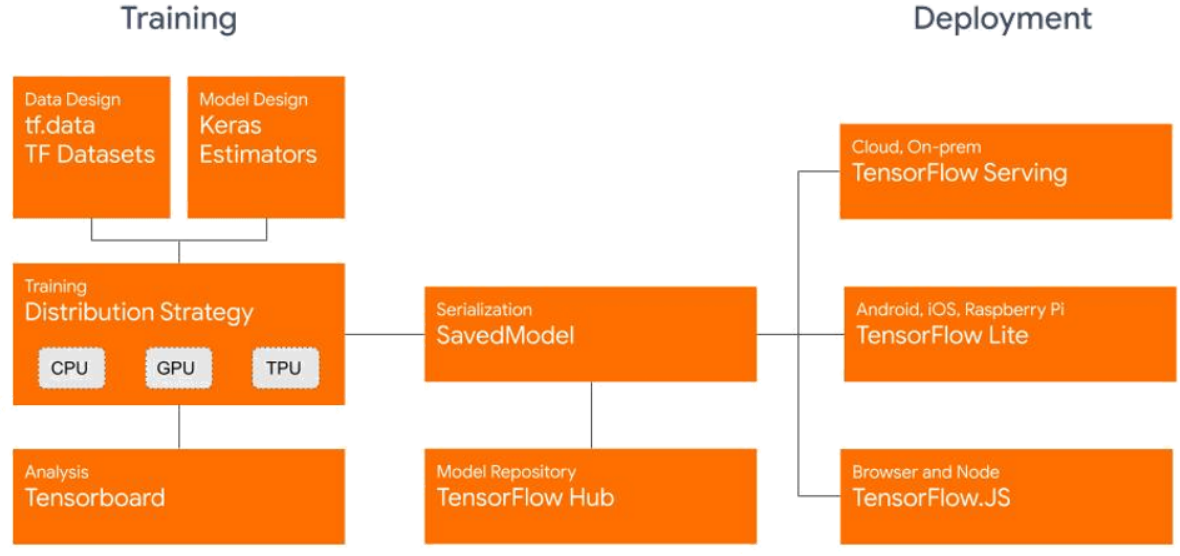

## 2）TensorFlow 2.0 vs 1.x

TensorFlow 1.x存在哪些问题？
- 文档和接口混乱
- 默认占用所有的GPU的所有内存
- 使用繁琐
- 调试困难
- 学习曲线陡峭

Tensorflow2.0 已经和 Pytorch 非常非常接近了，看下面 TensorFlow1.x, Pytorch, TensorFlow2.x 三者的对比！  
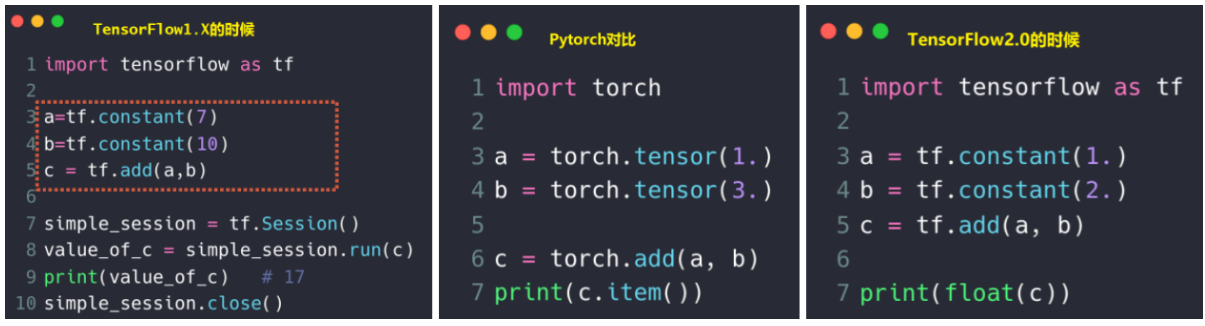

### 1. tf1.x 代码演示

In [ ]:
# import tensorflow as tf #2.0
import tensorflow.compat.v1 as tf#1.0
tf.disable_v2_behavior()#将v2版本功能关闭
a=tf.constant(7)
b=tf.constant(10)
c=tf.add(a,b)
print(a,b,c)#不能输出具体的值  返回的是op对象

2026-03-22 10:43:43.257490: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-22 10:43:43.257664: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-22 10:43:43.329511: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Instructions for updating:
non-resource variables are not supported in the long term
Tensor("Const:0", shape=(), dtype=int32) Tensor("Const_1:0", shape=(), dtype=int32) Tensor("Add:0", shape=(), dtype=int32)


In [2]:
with tf.Session() as sess:#开启会话  相当于开启计算图流水线
    res=sess.run(c) #在计算图中运行c
print(res)#输出具体的计算值

17


2026-03-22 10:45:01.603606: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.


### 2. tf2代码演示

In [1]:
import tensorflow as tf
a = tf.constant(7)
print(a)
b = tf.constant(10)
print(b)
c = tf.add(a, b)

print(c)
print(c.numpy()) #直接输出具体的值

2026-03-22 11:01:23.695426: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-22 11:01:23.695512: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-22 11:01:23.697642: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


tf.Tensor(7, shape=(), dtype=int32)
tf.Tensor(10, shape=(), dtype=int32)
tf.Tensor(17, shape=(), dtype=int32)
17


2026-03-22 11:01:26.484349: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.


### 3. Pytorch代码演示

In [ ]:
import torch
a = torch.tensor(7)
b = torch.tensor(10)
c = torch.add(a, b)

print(c) # 直接输出具体的值
print(c.item())

tensor(17)
17

TensorFlow 2.0删除了冗余API，使API更加一致（统—RNN，统一优化器）并通过Eager Execution更好地与Python运行时集成
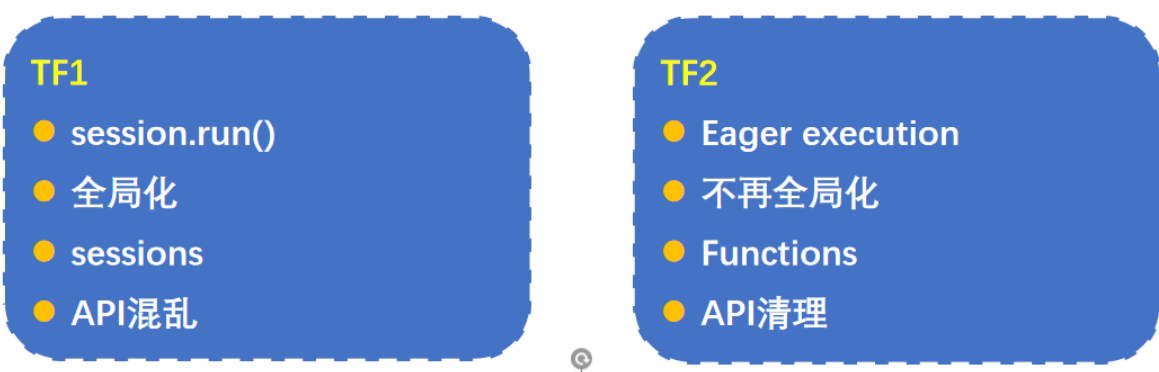  
TensorFlow 2.0推荐使用tf.keras,tf.data等高层库：
- 用 Eager 模式搭建原型
- 用 tf.data 处理数据
- 用 tf.feature_column 提取特征
- 用 tf.keras 搭建模型
- 用 tf.saved_model 打包模型

直接学习2.0即可

## 3）什么是Eager Execution？
- eager 模式就是类似于 python 这样的命令式编程，写好程序之后，不需要编译，就可以直接运行了，而且非常直观，方便调试;
- 而之前的Session静态图模式则类似于 C/C++的声明式编程。写好程序之后要先编译成静态计算图，然后才能运行，所以不方便调试。
- eager 模式是在 TF 1.4 版本之后引入的，在 TF 2.x的版本，会把 eager 模式变为默认执行模式。
- 好处∶  
    - 不需要编写完整的静态图调试
    - 不需要打开会话（Session）
    - Python 上调用它进行计算可以直接得出结果

## 4）Eager Execution优缺点
**优点∶**
- eager 模式提供了更直观的接口，可以像写 python 代码一样写模型;
- 更方便调试;
- 自然的控制流程，像编写 python 程序一样

**缺点：**
- 通过graph 构造的模型在分布式训练、性能优化以及线上部署上有优势;
- 推荐使用 @tf.function （而非1.X中的 tf.Session）实现Graph Execution从而将模型转换为易于部署且高性能的TensorFlow图模型。
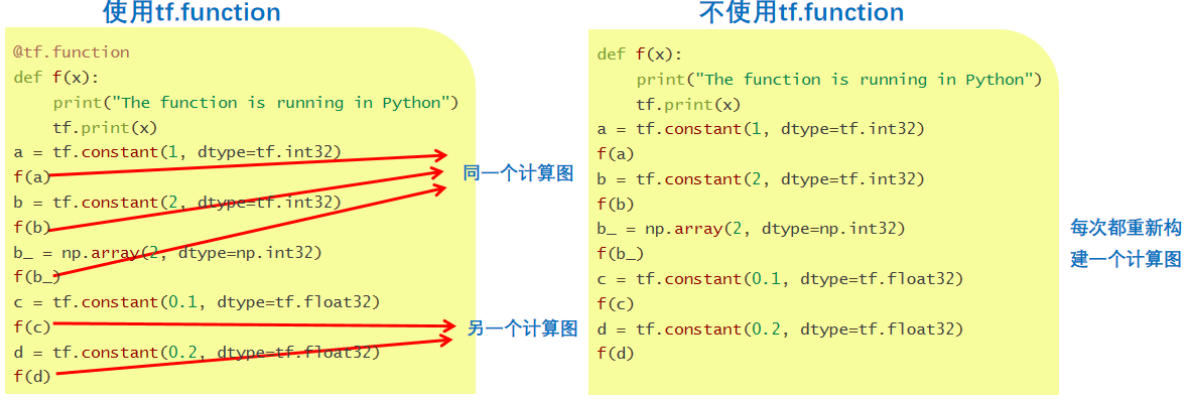

In [2]:
#不使用tf.function，每次执行都构建计算图再执行
import numpy as np
import tensorflow as tf
def f(x):
    print("The function is running in Python")
    tf.print(x)
    
a = tf.constant(1, dtype=tf.int32)
f(a)
b = tf.constant(2, dtype=tf.int32)
f(b)
b_ = np.array(2, dtype=np.int32)
f(b_)
c = tf.constant(0.1, dtype=tf.float32)
f(c)
d = tf.constant(0.2, dtype=tf.float32)
f(d)

The function is running in Python
1
The function is running in Python
2
The function is running in Python
array(2, dtype=int32)
The function is running in Python
0.1
The function is running in Python
0.2


In [3]:
#使用tf.function
@tf.function
def f(x):
    print("The function is running in Python")
    tf.print(x)
    
a = tf.constant(1, dtype=tf.int32)
f(a)
b = tf.constant(2, dtype=tf.int32)
f(b)#不来执行python函数 而是直接取tf的静态图上进行运行
b_ = np.array(2, dtype=np.int32)
f(b_)
c = tf.constant(0.1, dtype=tf.float32)
f(c)
d = tf.constant(0.2, dtype=tf.float32)
f(d)

The function is running in Python
1
2
2
The function is running in Python
0.1
0.2


# TensorFlow实战MNIST手写数字识别

## 1）加载数据集

In [4]:
import tensorflow as tf
import numpy as np

# 加载mnist数据集
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(type(x_train))
print(x_train[0], y_train[0])
# plt.imshow(x_train[0])
x_train, x_test = x_train / 255.0, x_test / 255.0 # 归一化
y_train_onehot = tf.keras.utils.to_categorical(y_train)  # 将标签转换成独热编码
y_test_onehot = tf.keras.utils.to_categorical(y_test)

11490434/11490434 [==============================] - 2s 0us/step
<class 'numpy.ndarray'>
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56 

## 2）搭建模型

In [5]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape = (28, 28)))
model.add(tf.keras.layers.Dense(128, activation = 'relu'))
model.add(tf.keras.layers.Dense(10, activation = 'softmax'))

## 3）训练模型

In [6]:
#loss函数使用交叉熵
# 顺序编码用sparse_categorical_crossentropy
# 独热编码用categorical_crossentropy
model.compile(optimizer = 'adam',
              loss = 'categorical_crossentropy',
              metrics = ['acc'])

history = model.fit(x_train, y_train_onehot, epochs=10)

model.evaluate(x_test, y_test_onehot)

Epoch 1/10


I0000 00:00:1774181711.064853    5804 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 [==============================] - 10s 4ms/step - loss: 0.2603 - acc: 0.9262
Epoch 2/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.1165 - acc: 0.9661
Epoch 3/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0820 - acc: 0.9747
Epoch 4/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0609 - acc: 0.9813
Epoch 5/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0484 - acc: 0.9849
Epoch 6/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.0372 - acc: 0.9886
Epoch 7/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0302 - acc: 0.9909
Epoch 8/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0237 - acc: 0.9926
Epoch 9/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0204 - acc: 0.9935
Epoch 10/10
313/313 [==============================] - 1s 4ms/step - loss: 0.0956 - acc: 0.9754


[0.09558210521936417, 0.9753999710083008]